Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

matplotlib import

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
url = "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Fish.csv"

df = pd.read_csv(url)

df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


species ount graph

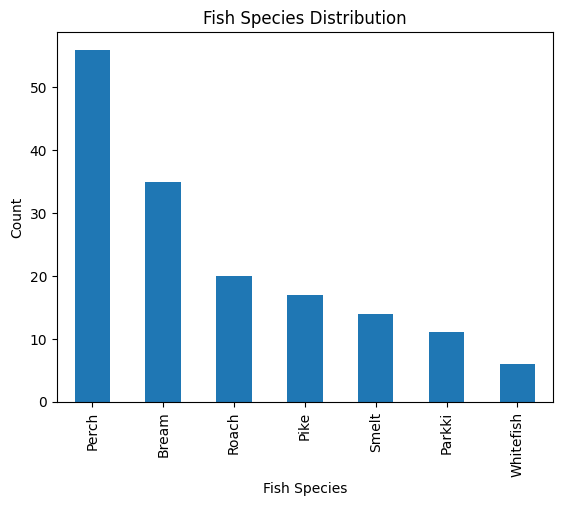

In [4]:
df['Species'].value_counts().plot(kind='bar')

plt.xlabel("Fish Species")
plt.ylabel("Count")
plt.title("Fish Species Distribution")

plt.show()

Display first five rows

In [5]:
print(df.head())

   Category Species  Weight   Height   Width  Length1  Length2  Length3
0         1   Bream   242.0  11.5200  4.0200     23.2     25.4     30.0
1         1   Bream   290.0  12.4800  4.3056     24.0     26.3     31.2
2         1   Bream   340.0  12.3778  4.6961     23.9     26.5     31.1
3         1   Bream   363.0  12.7300  4.4555     26.3     29.0     33.5
4         1   Bream   430.0  12.4440  5.1340     26.5     29.0     34.0


Encode Species

In [6]:
encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

weight distribution

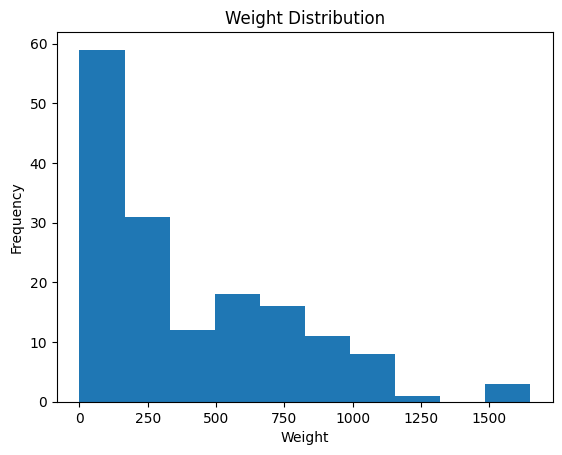

In [7]:
plt.hist(df['Weight'])

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Weight Distribution")

plt.show()

Length vs weight scatter

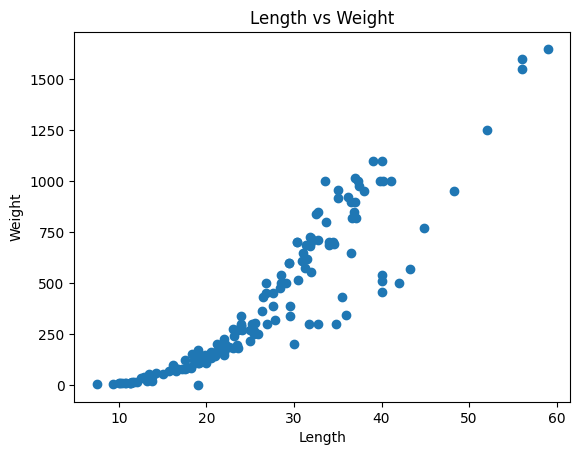

In [8]:
plt.scatter(df['Length1'], df['Weight'])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Length vs Weight")

plt.show()

Features and Target

In [9]:
X = df.drop("Species", axis=1)
y = df["Species"]

Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Model

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predictions

In [12]:
y_pred = model.predict(X_test)

Confusion matrix graph

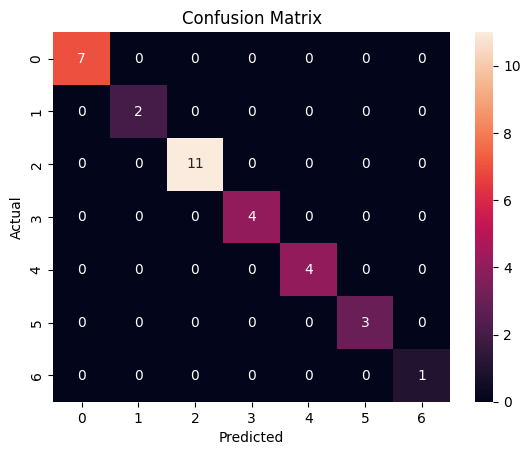

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Evaluation

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
# Convert classes to strings to avoid TypeError in formatting
target_names = [str(c) for c in encoder.classes_]

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       1.00      1.00      1.00        11
        Pike       1.00      1.00      1.00         4
       Roach       1.00      1.00      1.00         4
       Smelt       1.00      1.00      1.00         3
   Whitefish       1.00      1.00      1.00         1

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32


Confusion Matrix
[[ 7  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0]
 [ 0  0 11  0  0  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  4  0  0]
 [ 0  0  0  0  0  3  0]
 [ 0  0  0  0  0  0  1]]


Feature importance

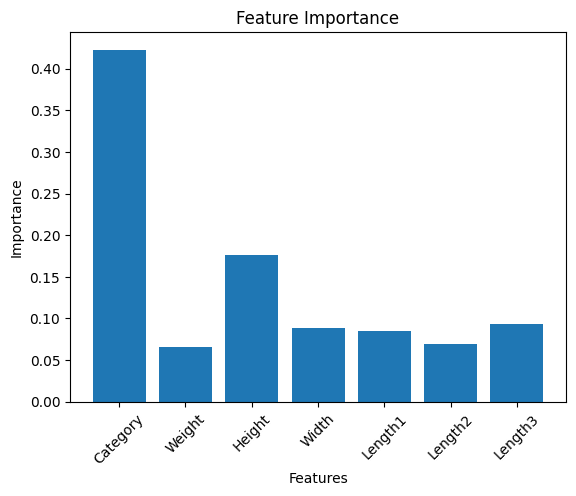

In [15]:
importance = model.feature_importances_

plt.bar(
    X.columns,
    importance
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()